# Uber Ride Pattern Analysis

## Objective
Analyze Uber ride data to identify travel patterns, peak ride hours, popular pickup and drop-off locations, trip purposes, and ride frequency trends.

# Tools Used
- Python
- Pandas
- SQL
- Power BI

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [9]:
df = pd.read_csv(r"C:\Users\tanis\Downloads\UberDataset.csv")

In [10]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [11]:
df.shape

(1156, 7)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [13]:
df.describe()

,MILES
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


In [14]:
# Missing Values
df.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [15]:
df['PURPOSE'].value_counts(dropna=False)

PURPOSE
NaN                503
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Commute              1
Charity ($)          1
Name: count, dtype: int64

In [21]:
df['PURPOSE'] = df['PURPOSE'].fillna('Unknown')
df['PURPOSE'] = df['PURPOSE'].fillna('Unknown')
df['PURPOSE'].value_counts(dropna=False)

PURPOSE
Unknown            503
Meeting            186
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Commute              1
Charity ($)          1
Name: count, dtype: int64

In [22]:
df.isnull().sum()

START_DATE    0
END_DATE      1
CATEGORY      1
START         1
STOP          1
MILES         0
PURPOSE       0
dtype: int64

In [23]:
df['CATEGORY'] = df['CATEGORY'].fillna('Unknown')

In [24]:
df = df.dropna(subset=['START', 'STOP'])

In [25]:
df = df.dropna(subset=['END_DATE'])

In [26]:
df.isnull().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

In [28]:
df.dtypes

START_DATE     object
END_DATE       object
CATEGORY       object
START          object
STOP           object
MILES         float64
PURPOSE        object
dtype: object

In [30]:
df[['START_DATE','END_DATE']].head()

,START_DATE,END_DATE
0,01-01-2016 21:11,01-01-2016 21:17
1,01-02-2016 01:25,01-02-2016 01:37
2,01-02-2016 20:25,01-02-2016 20:38
3,01-05-2016 17:31,01-05-2016 17:45
4,01-06-2016 14:42,01-06-2016 15:49


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1154 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1154 non-null   object 
 1   END_DATE    1154 non-null   object 
 2   CATEGORY    1154 non-null   object 
 3   START       1154 non-null   object 
 4   STOP        1154 non-null   object 
 5   MILES       1154 non-null   float64
 6   PURPOSE     1154 non-null   object 
dtypes: float64(1), object(6)
memory usage: 72.1+ KB


In [33]:
df['START_DATE'] = pd.to_datetime(
    df['START_DATE'],
    format='mixed'
)

df['END_DATE'] = pd.to_datetime(
    df['END_DATE'],
    format='mixed'
)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1154 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1154 non-null   datetime64[ns]
 1   END_DATE    1154 non-null   datetime64[ns]
 2   CATEGORY    1154 non-null   object        
 3   START       1154 non-null   object        
 4   STOP        1154 non-null   object        
 5   MILES       1154 non-null   float64       
 6   PURPOSE     1154 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 72.1+ KB


In [37]:
df['Hour'] = df['START_DATE'].dt.hour
df['Day'] = df['START_DATE'].dt.day_name()
df['Month'] = df['START_DATE'].dt.month_name()
df['Year'] = df['START_DATE'].dt.year

In [38]:
df[['Hour','Day','Year']].head()

,Hour,Day,Year
0,21,Friday,2016
1,1,Saturday,2016
2,20,Saturday,2016
3,17,Tuesday,2016
4,14,Wednesday,2016


In [73]:
df['Duration_Minutes'] = (
    df['END_DATE'] - df['START_DATE']
).dt.total_seconds() / 60

In [74]:
df[['START_DATE','END_DATE','Duration_Minutes']].head()

,START_DATE,END_DATE,Duration_Minutes
0,2016-01-01 21:11:00,2016-01-01 21:17:00,6.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,12.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,13.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,14.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,67.0


## Exploratory Data Analysis

##### Question 1:
##### Business vs Personal Rides

In [39]:
df['CATEGORY'].value_counts()

CATEGORY
Business    1077
Personal      77
Name: count, dtype: int64

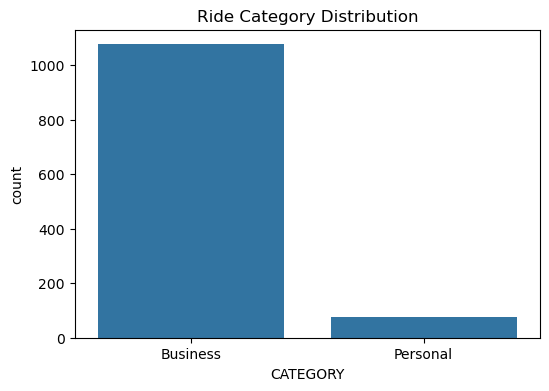

In [40]:
plt.figure(figsize=(6,4))
sns.countplot(x='CATEGORY', data=df)
plt.title("Ride Category Distribution")
plt.show()

##### Business rides dominate the dataset, indicating Uber is frequently used for work-related travel.

##### Question 2:
##### Most Frequent Start Locations

In [42]:
top_start = df['START'].value_counts().head(10)

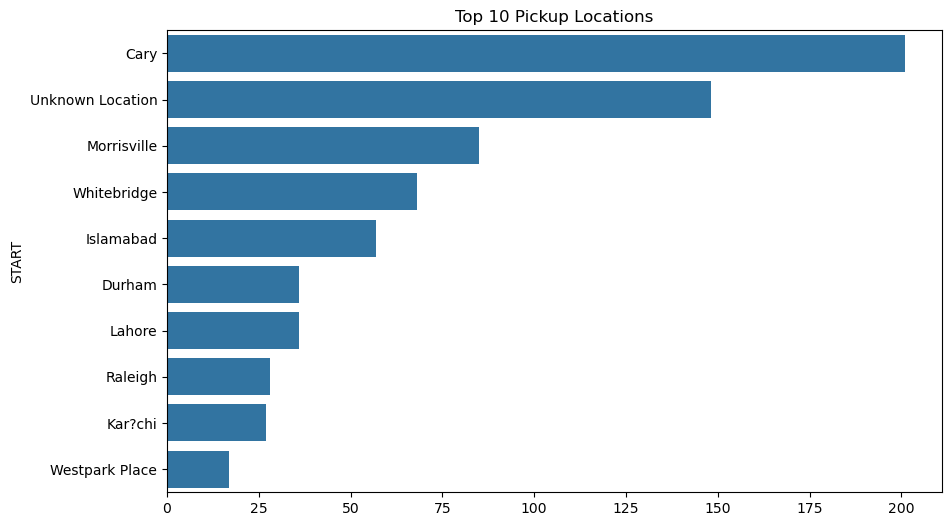

In [43]:
plt.figure(figsize=(10,6))
sns.barplot(
    x = top_start.values,
    y = top_start.index
)
plt.title("Top 10 Pickup Locations")
plt.show()

##### Question 3:
##### Most Frequent Destinations

In [44]:
top_stop = df['STOP'].value_counts().head(10)

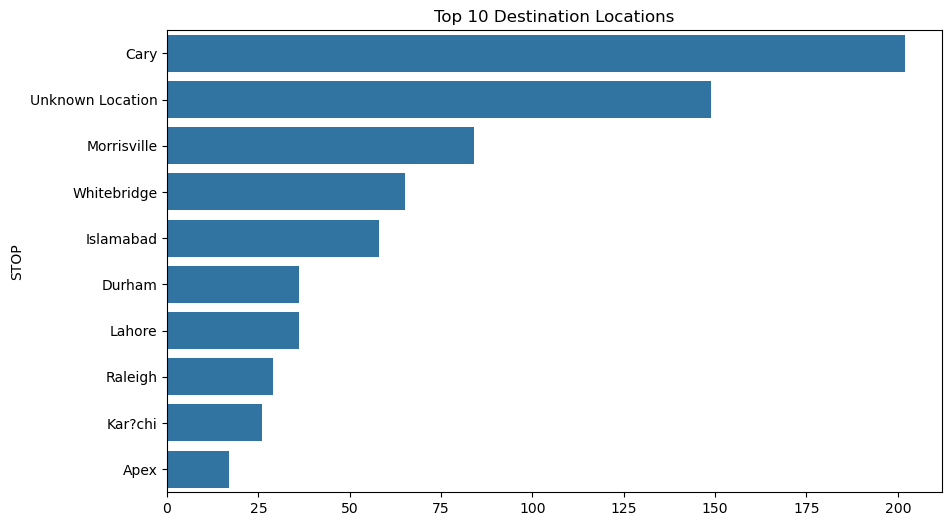

In [45]:
plt.figure(figsize=(10,6))
sns.barplot(
    x = top_stop.values,
    y = top_stop.index
)
plt.title("Top 10 Destination Locations")
plt.show()

##### Question 4:
##### Peak Ride Hours

In [47]:
hourly = df['Hour'].value_counts().sort_index()

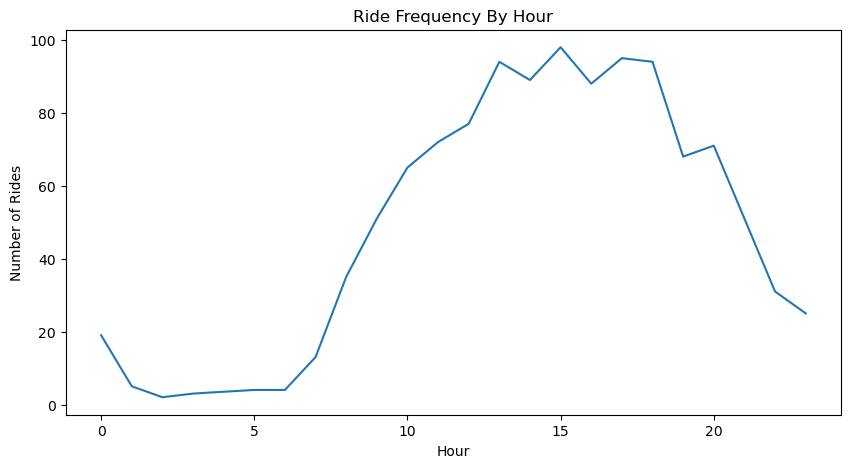

In [48]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x = hourly.index,
    y = hourly.values
)
plt.title("Ride Frequency By Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.show()

##### Most rides occur during commuting and business hours.

##### Question 5:
##### Day-wise Ride Trends

In [49]:
daywise = df['Day'].value_counts()

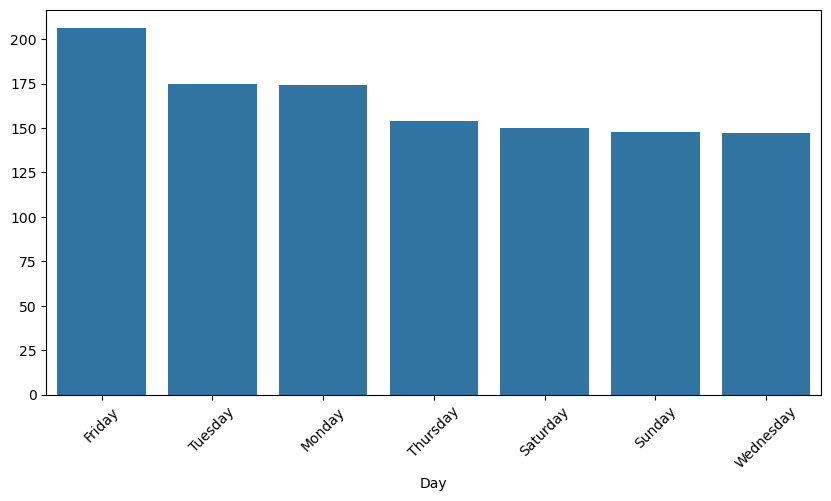

In [50]:
plt.figure(figsize=(10,5))
sns.barplot(
    x = daywise.index,
    y = daywise.values
)
plt.xticks(rotation=45)
plt.show()

##### Question 6:
##### Monthly Ride Trends

In [57]:
month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

monthly = df['Month'].value_counts().reindex(month_order)

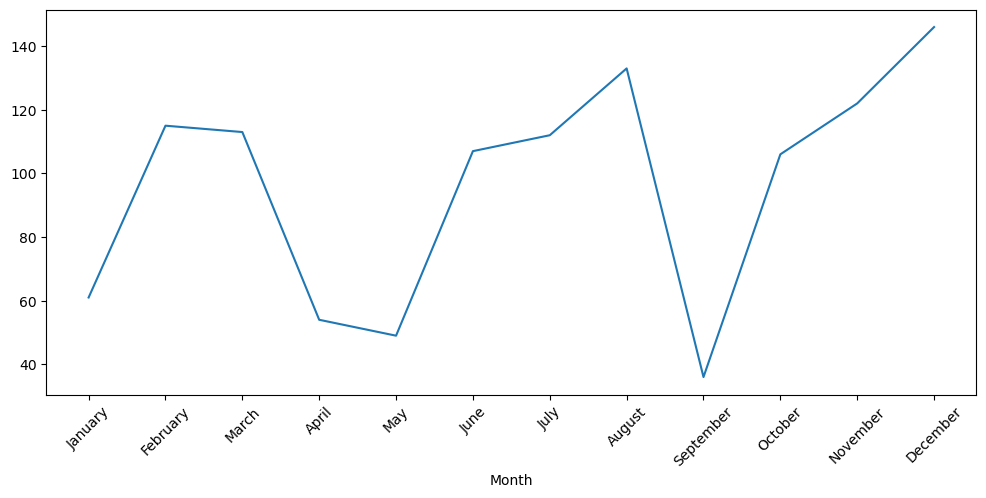

In [62]:
plt.figure(figsize=(12,5))
sns.lineplot(
    x=monthly.index,
    y=monthly.values
)
plt.xticks(rotation=45)
plt.show()

##### Question 7:
##### Trip Distance Analysis

In [63]:
df['MILES'].mean()

np.float64(10.567417677642982)

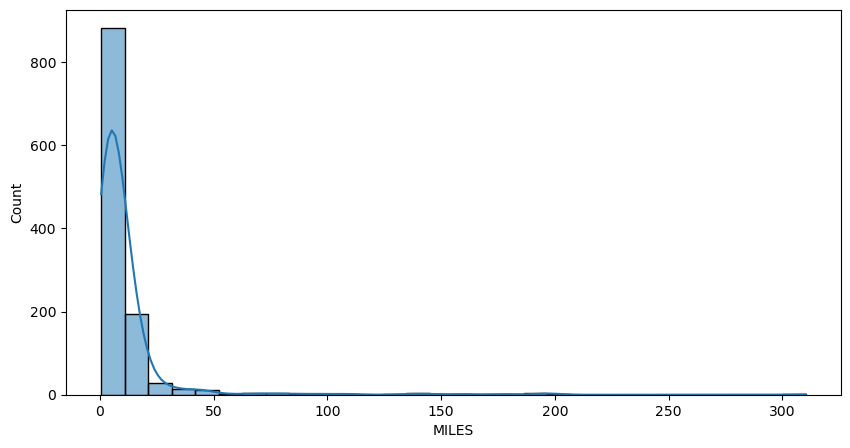

In [67]:
plt.figure(figsize=(10,5))
sns.histplot(
    df['MILES'],
    bins=30,
    kde=True
)
plt.show()

##### Question 8:
##### Ride Purpose Analysis

In [68]:
purpose = df['PURPOSE'].value_counts()

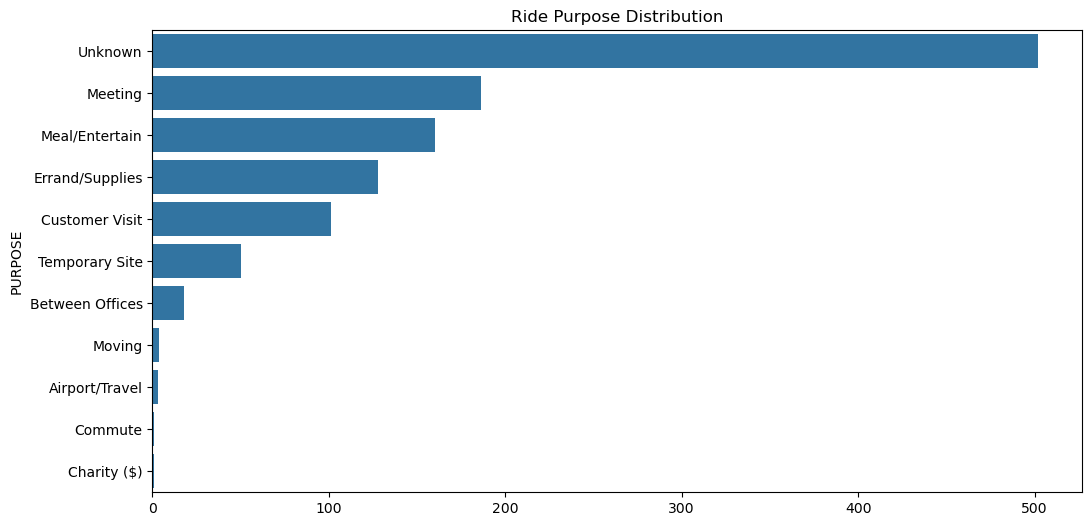

In [69]:
plt.figure(figsize=(12,6))
sns.barplot(
    x = purpose.values,
    y = purpose.index
)
plt.title("Ride Purpose Distribution")
plt.show()

In [75]:
df.to_csv(r"C:\Users\tanis\Downloads\uber_cleaned.csv", index=False)